# **Spectral type pdf flagger part 2: SPLIT (Source-type Probability from Likelihood Identification Tool).**

## **0. Initialization**

### 0.1. Packages

In [70]:
### Import libraries ###
%matplotlib inline
import re
import os
import sys
from importlib import reload
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps

from sklearn.feature_selection import f_classif
import scipy.interpolate as sip
from scipy.stats import gaussian_kde

In [71]:
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(base_dir)
from scripts import statsplot as lsp
import scripts.utils as sutils; reload(sutils)

<module 'scripts.utils' from '/home/hallouin/Documents/t_hall/lephare/stargal/scripts/utils.py'>

### 0.2. Tables

In [72]:
### The initial table, used in LePHARE
dp02_dc2_62_table = pd.read_csv(f'{base_dir}/simulation_catalogs/DC2/dp02_dc2_62.csv')

### The table in which is gathered the statistics compute from each onesource
training_sample_features = pd.read_csv(f'{base_dir}/simulation_catalogs/star_gal/training_sample_features.csv')

### The table of best fit statistical parameters
best_fit_distribution = pd.read_csv(f'{base_dir}/simulation_catalogs/star_gal/best_fit_distribution.csv')

In [133]:
# Let's make it one and keep the interesting features. (colnames: best_fit_distribution.columns)
training_sample = sutils.join_tables(training_sample_features, [(dp02_dc2_62_table[['mt_match_objectId', 'ts_truth_type', 'imag', 'imag_err']], 'source_id', 'mt_match_objectId'), 
        (best_fit_distribution[['source_id', 'best_sed_id', 'Teff_best', 'logg_best', 'FeH_best', 'chi2_best']], 'source_id', 'source_id')], 
        how='left')

In [134]:
training_sample[:3]

,source_id,npeaks_Teff,peakratio_Teff,std_Teff,npeaks_logg,peakratio_logg,std_logg,npeaks_FeH,peakratio_FeH,std_FeH,...,delta_chi2,mt_match_objectId,ts_truth_type,imag,imag_err,best_sed_id,Teff_best,logg_best,FeH_best,chi2_best
0,1651413688361421449,1,0.028793,609.066670,1,0.942599,1.690101,0,0.727342,1.035656,...,0.0024,1651413688361421449,2,25.452401,0.190892,907,4800.0,3.0,-3.0,5.5427
1,1651413688361451863,1,0.008300,69.456168,1,0.287778,0.746080,1,0.151169,0.794221,...,0.3330,1651413688361451863,2,24.611190,0.082115,755,4000.0,3.5,0.5,19.8090
2,1651413688361451723,3,0.300111,9474.808806,2,0.715919,1.398000,0,0.932259,1.061343,...,0.0065,1651413688361451723,1,26.705990,0.361728,104,10800.0,3.5,-3.0,6.9235


In [135]:
star_training_sample = training_sample[training_sample["ts_truth_type"]==2]
gal_training_sample = training_sample[training_sample["ts_truth_type"]==1]

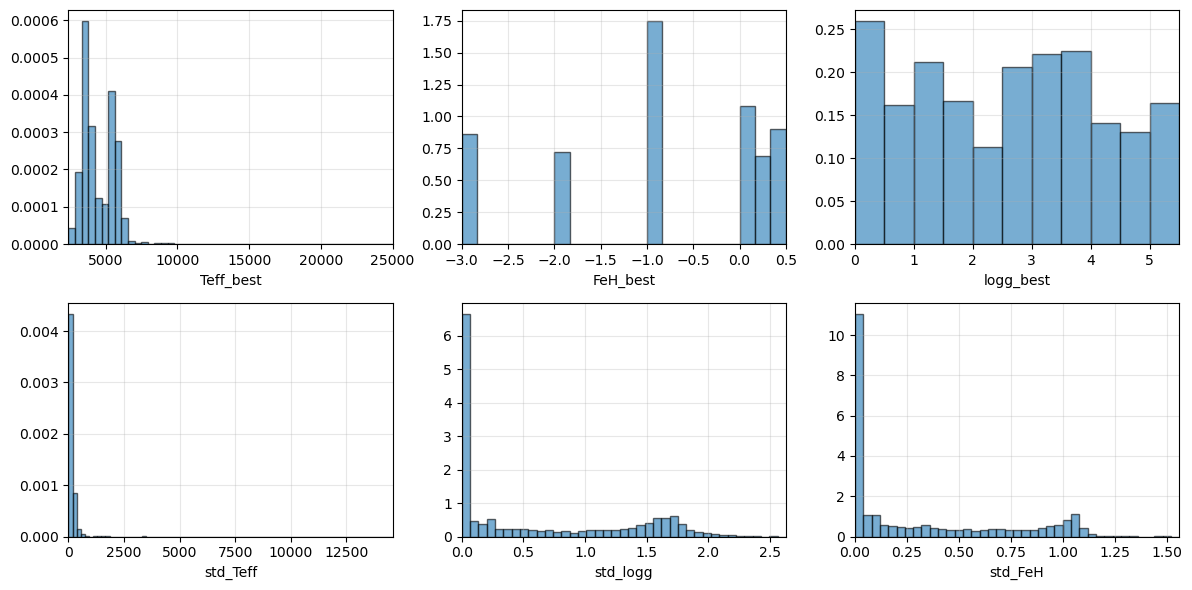

In [136]:
lsp.histograms(star_training_sample, xrange=None, log=False, bins=[50, 22, 12, 80, 40, 40, 40], 
                 col=['Teff_best', 'FeH_best', 'logg_best', #col to plot
                      'std_Teff', 'std_logg', 'std_FeH'],
                      density=True, alpha=0.6) #histkwargs

# lsp.histograms(gal_training_sample, xrange=None, log=False, bins=[50, 22, 12, 80, 40, 40, 40],
#                  col=['Teff_best', 'FeH_best', 'logg_best', #col to plot
#                       'std_Teff', 'std_logg', 'std_FeH'],
#                       density=True, alpha=0.6) #histkwargs

## **1. SPLIT training**

Now that we have fully characterized the star-pdfs, we can use them as a discretizer. To do so, we look at the distribution of each statistical feature of a "training sample", depending of the source type. Then for a source for which the type is unknow we see if it fits better the usual statistics of a star or a galaxy. It is like a likelihood of a likelihood. 

### 1.1 Utils

In [137]:
def make_bins(mask_min, mask_max, nbins, logscale=False):
    if logscale:
        return np.logspace(np.log10(max(mask_min, 1e-6)),
                            np.log10(mask_max), nbins)
    else:
        return np.linspace(mask_min, mask_max, nbins)

def shift_bins(edges):
    edges = np.asarray(edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    first = centers[0] - (centers[1] - centers[0])
    last  = centers[-1] + (centers[-1] - centers[-2])
    return np.concatenate([[first], centers, [last]])


### 1.2 Make statistics distribution functions

In [138]:
from scipy.integrate import quad
class SPLIT_TRAINING:
    """
    Prepare the statistical feature distributions for the classification.
    """

    def list_to_pdf(self, data, interp=False, bins=100, recenter_bins=True, xrange=None, smooth_eps=1e-9, normalize=True):
        """
        Compute the pdf from a data array.

        Parameters
        ----------
        data: list or np.darray
            Array to compute the pdf from.
        interp: Bool or str.
            Interpolation method to build the pdf.
        bins: int or list or np.darray.
            Bins used to compute the histogram used in <scipy.interpolate.{interp}> methods.
        recenter_bins: bool.
            If True, recenter the bins over the bin edges. Useful when using a list in bins
        xrange: tuple.
            Range to compute the pdf within.
        smooth_eps: float.
            Zero probability value.
        
        Returns
        -------
        pdf: pdf function.
        """
        if interp in ('scott', 'silverman') or isinstance(interp,(float,int)) and interp!=False:
            kde = gaussian_kde(data, bw_method=interp)
            def pdf(x):
                return kde(x)
            return pdf

        if recenter_bins==True and not isinstance(bins, int):
            new_bins = shift_bins(bins)
            counts, _ = np.histogram(data, bins=new_bins, range=xrange, density=True)
            x = bins
        else:
            counts, bin_edges = np.histogram(data, bins=bins, range=xrange, density=True)
            x=0.5 * (bin_edges[:-1] + bin_edges[1:])
        
        counts = counts + smooth_eps
        # --- Interpolation ---
        if interp == 'pchip':
            pdf_raw = sip.PchipInterpolator(x, counts, extrapolate=False)
        else:
            pdf_raw = sip.interp1d(x, counts, kind=interp, bounds_error=False, fill_value=0.0)

        # --- Normalization ---
        if normalize==True:
            xmin, xmax = min(x), max(x)
            Z, _ = quad(pdf_raw, xmin, xmax, limit=1000)

            if Z <= 0 or not np.isfinite(Z):
                raise ValueError("PDF normalization failed (integral <= 0).")

            def pdf(x):
                return pdf_raw(x) / Z
        else:
            pdf = pdf_raw

        return pdf

    def pdfs_from_arrays(self, arrays, **ltpkwargs):
        """
        Return the pdf from two arrays and compute the weight if specified.

        Parameters
        ----------
        arrays: tuple of (list or np.darray)
            Arrays to compute the pdfs from.
        ltpkwargs: args of <list_to_pdf> method.
        Returns
        -------
        pdfs: list of pdf methods.
        """
        pdfs = []
        for dist in arrays:
            pdf = self.list_to_pdf(dist, **ltpkwargs)
            pdfs.append(pdf)

        return pdfs

    def compute_weight(self, source_feats, source_labels, method='f_classif'):
        """
        Compute weight by comparing feature distributions between several classes.
        The weight determine if the feature is relevant to be used to compare the classes.

        Parameters
        ----------
        source_feats: list of (list or np.darray)
            Array of dimension N_sources x N_features.
            Each element corresponds to a source, and each element of a row is a statistical feature.
        source_labels: list of (str, int...).
            The list of label corresponding to each source.
        method: str.
            The method to use to compute weight (fisher or f_classic)
        Returns
        -------
        List of weights of length N_features.
        """
        source_feats = np.asarray(source_feats)
        source_labels = np.asarray(source_labels)

        if method == 'fisher':
            classes = np.unique(source_labels)
            n_features = source_feats.shape[1]
            weights = np.zeros(n_features)
            global_mean = np.mean(source_feats, axis=0)
            for j in range(n_features):
                num = 0.0  # inter-class variance
                den = 0.0  # intra-class variance
                for c in classes:
                    mask = source_labels == c
                    x_c = source_feats[mask, j]
                    if len(x_c) < 2:
                        continue
                    mean_c = np.mean(x_c)
                    var_c = np.var(x_c)
                    num += len(x_c) * (mean_c - global_mean[j])**2
                    den += len(x_c) * var_c
                weights[j] = num / den if den > 0 else 0.0

        elif method == 'f_classif':
            f_statistic, _ = f_classif(source_feats, source_labels)
            weights = f_statistic

        else:
            raise NotImplementedError(
                f"Weight method '{method}' not recognized."
            )

        # --- normalisation ---
        weights = np.nan_to_num(weights, nan=0.0, posinf=0.0)
        if np.sum(weights) > 0:
            weights /= np.sum(weights)
        return weights

    def pdfs_from_sample(self, training_df, label_column, scols=None, exclude_scols=False, 
                        compute_weight=False, weight_method='fisher', selectKbest=None, 
                        custo_bins_interp=None, **ltpkwargs):
        """
        Compute the pdf for each class, for each features.

        Parameters
        ----------
        dfs: pandas.dataframe.
            df to compute the pdfs from. It must contain at leats a label column,
            and the features columns to compute the pdfs from. Each row is a source.
        label_column: str.
            Column holding the label attributed to each source. 
        scols: str or list of.
            Selected columns to compute the pdfs from is [{col_name}],
            or to ignore if ~[{col_name}].
        exclude_scols: bool.
            If True, scols are now the columns to exclude from the computations.
        compute_weight: bool.
            If true, return the weight of each statistical feature.
        custo_bins_interp: tuple (str, list) or list of.
            If specified, for each col in custo_bins_interp[0], list_to_pdf uses the bins in custo_bins_interp[1].
        ltpkwargs: args of <list_to_pdf> method.
        Returns
        -------
        pdfs_dict: Dict
            pdf functions, with weights if True.
        """

        # --- Select feature columns ---
        if scols is not None:
            if exclude_scols==True:
                cols = [c for c in training_df.columns
                            if c not in scols
                            and c != label_column]
            elif exclude_scols==False:
                cols = [c for c in training_df.columns
                            if c in scols
                            and c != label_column]
                
        else:
            cols = training_df.drop(columns=[label_column]).columns.tolist()
        # --- extract features / labels ---
        features_values = training_df[cols].values.astype(float) # Nsources(rows) x Nfeatures(cols)
        source_labels = training_df[label_column].values # Nsources
        unique_labels = np.unique(source_labels)
        # --- compute weights ---
        if compute_weight==True:
            weights = self.compute_weight(features_values, source_labels, method=weight_method)
            # select the k best weight features from weights
            if isinstance(selectKbest, int):
                idx = np.argsort(weights)[::-1][:selectKbest]
                cols = [cols[i] for i in idx]
                weights = weights[idx]
                features_values = features_values[:, idx]

                weights /= np.sum(weights)
        else:
            weights = np.ones(len(cols)) / len(cols)

        # --- Build pdf dictionary ---
        # len(source_labels)*N_features = N_pdfs
        custo_map = None
        if custo_bins_interp is not None:
            custo_map = {}
            for item in custo_bins_interp:
                if len(item) != 3:
                    raise ValueError(
                        "Each element of custo_bins_interp must be (col, bins, interp)"
                    )
                col, bins, interp = item
                custo_map[col] = {"bins": bins, "interp": interp}

        pdf_dict = {}
        for i, col in enumerate(cols):
            pdfs = {}

            for label in unique_labels:
                mask = source_labels == label
                data = features_values[mask, i]

                local_kwargs = ltpkwargs
                # --- Apply custom bins / interp if specified ---
                if custo_map is not None and col in custo_map:
                    if custo_map[col]["bins"] is not None:
                        local_kwargs["bins"] = custo_map[col]["bins"]
                    if custo_map[col]["interp"] is not None:
                        local_kwargs["interp"] = custo_map[col]["interp"]
                pdfs[label] = self.list_to_pdf(data, **local_kwargs)
            pdf_dict[col] = {"pdfs": pdfs, "weight": weights[i]}

        return pdf_dict
        


### 1.3 Test on the sample

In [139]:
split_training=SPLIT_TRAINING()

We selected the SEDs using a discrete list of physical quantities. Thus we can use it to make the bins of the probability function since Teff_best, FeH_best and logg_best are discrete too.

In [140]:
teff_values = list(range(800, 7200, 400)) + list(range(7200, 12001, 600)) + list(range(12500, 25001, 5000)) + list(range(25000, 50001, 5000))
logg_values = np.arange(0.0, 5.6, 0.5)
feh_values = [-3, -2, -1, 0.0, 0.3, 0.5]

In [141]:
#Note: the star sed library used for the tests held 1622 seds at the creation of this notebook
sed_id_bins = np.arange(0,1622,1)

In [143]:
pdf_dict = split_training.pdfs_from_sample(
    training_sample,
    label_column="ts_truth_type",
    scols=["source_id", "npeaks_Teff", "npeaks_logg", 'npeaks_FeH', 'mt_match_objectId', 'ts_truth_type', 'chi2_best','imag', 'imag_err'],
    compute_weight=True,
    weight_method="f_classif",
    exclude_scols=True,
    selectKbest=None,
    bins=1000,
    interp=False,
    custo_bins_interp=[("Teff_best", teff_values, False),("logg_best", logg_values, False),("FeH_best", feh_values, False),('best_sed_id', sed_id_bins,None)],
    recenter_bins=True,
    normalize=True
)

/tmp/ipykernel_11826/2037031583.py:54: IntegrationWarning: The maximum number of subdivisions (1000) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Z, _ = quad(pdf_raw, xmin, xmax, limit=1000)


In [144]:
def prob_plot(data, pdfs, labels=None, feature=None,
                bins=50, xrange=None):
    """
    Plot PDFs and histograms for one feature.

    Parameters
    ----------
    data : pandas.DataFrame or list of arrays
        Data to plot histograms from.
    pdfs : list of callables or dict
        PDFs corresponding to each class (ignored if pdfs_dict is provided).
    labels : list, optional
        Class labels if data AND pdfs are arrays. Can use column name of class labels
        if data is DataFrame OR pdfs a dict. 
    bins : int or array-like
        Histogram bins.
    recenter_bins : bool
        Recenter bins if array-like.
    feature : str, optional
        Feature name to plot (required if pdfs_dict is provided).
    xrange : tuple, optional
        (xmin, xmax) range for plotting.
    """
    # --- Handle pdfs format ---
    if isinstance(pdfs, dict):
        pdf_list = list(pdfs[feature]['pdfs'].values())
    elif isinstance(pdfs, list):
        pdf_list = pdfs
    else:
        raise ValueError('pdfs must be a list of callables or a dict')

    # --- Handle labels format ---
    if isinstance(labels, str) and isinstance(data, pd.DataFrame):
        label_list = list(np.unique(data[labels]))
    elif isinstance(labels, list):
        label_list = labels
    elif labels==None and isinstance(pdfs, dict):
        label_list = list(pdfs[feature]['pdfs'].keys())
    elif labels==None and not isinstance(pdfs, dict):
        label_list = [f"class {i}" for i in range(len(pdfs))]
    else:
        raise ValueError('Labels must be a list of labels or a str coupled with a pandas.dataframe.')

    # --- Handle data format ---
    if isinstance(data, pd.DataFrame):
        if feature is None:
            raise ValueError("feature must be specified when data is a DataFrame.")
        if not isinstance(labels, str):
            raise ValueError("labels must be provided as str when data is a DataFrame.")
        data_arrays = [data.loc[data[labels] == l, feature].values for l in label_list]
    else:
        data_arrays = [np.asarray(d) for d in data]

    if len(data_arrays) != len(pdf_list):
        raise ValueError("Number of data arrays and pdfs must match.")

    # --- Plot ---
    plt.figure(figsize=(6, 5))
    cmap = plt.get_cmap("tab20")
    i=0
    for arr, pdf, lab in zip(data_arrays, pdf_list, label_list):
        if isinstance(bins, int):
            _, bin_edges, _ = plt.hist(arr, bins=bins, density=True, label=f"hist {lab}", color=cmap(i), alpha=0.3)
            x=0.5 * (bin_edges[:-1] + bin_edges[1:])
        if isinstance(bins, (list, np.ndarray)):
            x = np.asarray(bins)
            plt.hist(arr, bins=shift_bins(bins), density=True, label=f"hist {lab}", color=cmap(i), alpha=0.3)
            
        plt.plot(x, pdf(x), linestyle='--', label=f"pdf {lab}", c=cmap(i))
        i+=2

    plt.xlabel(feature if feature is not None else "x")
    plt.ylabel("PDF")
    plt.legend()
    plt.tight_layout()
    plt.show()


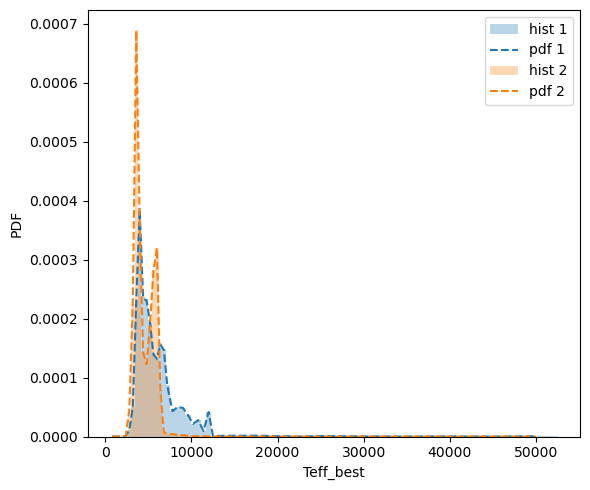

In [145]:
%matplotlib inline
# prob_plot(data=training_sample, pdfs=pdf_dict, labels='ts_truth_type', feature='peakratio_logg', bins=1000)
# prob_plot(data=training_sample, pdfs=pdf_dict, labels='ts_truth_type', feature='best_sed_id', bins=sed_id_bins)
prob_plot(data=training_sample, pdfs=pdf_dict, labels='ts_truth_type', feature='Teff_best', bins=teff_values)

# Note that if you use normalized pdf (normalize=True), it will not exactly fit the normalized histograms (density=True).
# Note 2: for the moment the most efficient technic seems to do not interpolate when the sample is big

## **SPLIT**

The main part of SPLIT.

In [146]:
for key in pdf_dict.keys():
    print(key,':', pdf_dict[key]['weight'])

peakratio_Teff : 0.009691006997273315
std_Teff : 0.0152457375679279
peakratio_logg : 0.06303428958209081
std_logg : 0.09002340179881191
peakratio_FeH : 0.06752870095629881
std_FeH : 0.1034524227066853
cov_Teff_logg_xx : 0.006577503054273287
cov_Teff_logg_yy : 0.05180197520160238
cov_Teff_logg_xy : 0.006017275062585746
axisratio_Teff_logg : 1.2258978347306054e-07
area_Teff_logg_p50 : 0.008537096962681217
area_Teff_logg_p90 : 0.00415864523164769
cov_Teff_FeH_xx : 0.007459016370595409
cov_Teff_FeH_yy : 0.07456817112287932
cov_Teff_FeH_xy : 4.658909095908752e-05
axisratio_Teff_FeH : 5.619664923930869e-07
area_Teff_FeH_p50 : 0.006790975051024077
area_Teff_FeH_p90 : 0.0032435420300332704
cov_logg_FeH_xx : 0.05459969449768425
cov_logg_FeH_yy : 0.07559016254249958
cov_logg_FeH_xy : 0.001457907476138071
axisratio_logg_FeH : 0.0012039790980773813
area_logg_FeH_p50 : 0.0380306008492776
area_logg_FeH_p90 : 0.014088986057036656
entropy : 0.12281583112244054
concentration_dchi2_1 : 0.107769774717564

In [147]:
class SPLIT:
    """
    Class where appends the main part of split. 

    Init with the pdf dict created with <SPLIT_TRAINING>.
    """
    def __init__(self, pdf_dict):
        self.pdf_dict = pdf_dict
        self.features = list(pdf_dict.keys())
        self.classes = list(
            next(iter(pdf_dict.values()))['pdfs'].keys()
        )

    def feature_loglikelihood(self, x, feature, eps=1e-12):
        """
        Compute log p(x | class) for a given feature.
        """
    
        pdfs = self.pdf_dict[feature]['pdfs']

        logL = []

        for c in self.classes:
            p = pdfs[c](x)
            p = np.maximum(p, eps)
            logL.append(np.log(p))

        return np.array(logL)

    def class_prob(self, onesource, priors=None, use_weights=False, eps=1e-12):
        """
        Compute the probability of a source to belong to each class using <self.post_prob>.

        Parameters:
        -----------
        onesource: the source to evaluate the class on. Can be a list of features corresponding to the pdfs

        priors: None or list of float of length = len(pdfs).
            If specified, take priors in account.
        use_weights: bool
            If True, uses the feature weights specified in pdfs.
        
        Return:
        -------
        probs: list of floats
            List of probabilies to belong to the classes.
            
        """
        n_classes = len(self.classes)

        if priors is None:
            priors = np.ones(n_classes) / n_classes
        else:
            priors = np.asarray(priors)

        log_post = np.log(priors)

        for feature in self.features:

            x = onesource[feature]

            logL_feat = self.feature_loglikelihood(x, feature, eps)

            if use_weights:
                w = self.pdf_dict[feature]['weight']
                log_post += w * logL_feat
            else:
                log_post += logL_feat

        # softmax stable
        max_log = np.max(log_post)
        exp_log = np.exp(log_post - max_log)
        probs = exp_log / np.sum(exp_log)

        return probs

    def classify_sample(self, df, priors=None, use_weights=False):

        results = []

        for _, row in df.iterrows():
            probs = self.class_prob(
                row,
                priors=priors,
                use_weights=use_weights
            )
            results.append(probs)

        posterior = np.vstack(results)
        
        return pd.DataFrame(
            posterior,
            columns=[f"P_{c}" for c in self.classes],
            index=df.index
        )


In [148]:
split = SPLIT(pdf_dict)

In [149]:
probs = split.classify_sample(training_sample, priors=None, use_weights=True)

In [150]:
training_sample

,source_id,npeaks_Teff,peakratio_Teff,std_Teff,npeaks_logg,peakratio_logg,std_logg,npeaks_FeH,peakratio_FeH,std_FeH,...,delta_chi2,mt_match_objectId,ts_truth_type,imag,imag_err,best_sed_id,Teff_best,logg_best,FeH_best,chi2_best
0,1651413688361421449,1,0.028793,609.066670,1,0.942599,1.690101,0,0.727342,1.035656,...,0.00240,1651413688361421449,2,25.452401,0.190892,907,4800.0,3.0,-3.0,5.5427
1,1651413688361451863,1,0.008300,69.456168,1,0.287778,0.746080,1,0.151169,0.794221,...,0.33300,1651413688361451863,2,24.611190,0.082115,755,4000.0,3.5,0.5,19.8090
2,1651413688361451723,3,0.300111,9474.808806,2,0.715919,1.398000,0,0.932259,1.061343,...,0.00650,1651413688361451723,1,26.705990,0.361728,104,10800.0,3.5,-3.0,6.9235
3,1651413688361451008,1,0.305878,10671.099396,1,0.841672,1.521270,0,0.964616,1.063425,...,0.03000,1651413688361451008,1,27.495085,0.793405,1522,9000.0,2.5,-3.0,4.8960
4,1651413688361450766,1,0.044406,964.602281,0,0.854164,1.578001,0,0.875371,1.066910,...,0.00066,1651413688361450766,1,25.917630,0.254179,1163,6400.0,0.0,0.5,0.5001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267032,1651220174314963390,1,0.010950,199.041415,1,0.440143,1.117811,0,0.199642,0.416923,...,0.07500,1651220174314963390,1,24.034992,0.039934,1136,6000.0,3.5,-3.0,73.7000
267033,1651220174314979605,1,0.066305,6252.085024,1,0.855560,1.603514,0,0.768774,1.030931,...,0.00920,1651220174314979605,1,26.259573,0.257267,1154,6000.0,5.0,-3.0,5.1012
267034,1651220174314968068,1,0.069575,1520.112444,0,0.200287,1.818729,1,0.937672,1.047902,...,0.03600,1651220174314968068,1,25.860497,0.208592,1491,9000.0,0.0,-2.0,16.7200
267035,1567956357766723215,1,0.192838,10507.527073,2,0.841718,1.575019,1,0.980332,1.063779,...,0.00260,1567956357766723215,1,26.612160,0.478872,1298,7200.0,0.5,-3.0,1.9574


In [151]:
final = pd.concat([training_sample, probs], axis=1)

In [180]:
mask = (final['ts_truth_type']==1) & (final['imag_err']<1)
final[mask]

,source_id,npeaks_Teff,peakratio_Teff,std_Teff,npeaks_logg,peakratio_logg,std_logg,npeaks_FeH,peakratio_FeH,std_FeH,...,ts_truth_type,imag,imag_err,best_sed_id,Teff_best,logg_best,FeH_best,chi2_best,P_1,P_2
2,1651413688361451723,3,0.300111,9474.808806,2,0.715919,1.398000,0,0.932259,1.061343,...,1,26.705990,0.361728,104,10800.0,3.5,-3.0,6.9235,0.989585,0.010415
3,1651413688361451008,1,0.305878,10671.099396,1,0.841672,1.521270,0,0.964616,1.063425,...,1,27.495085,0.793405,1522,9000.0,2.5,-3.0,4.8960,0.997421,0.002579
4,1651413688361450766,1,0.044406,964.602281,0,0.854164,1.578001,0,0.875371,1.066910,...,1,25.917630,0.254179,1163,6400.0,0.0,0.5,0.5001,0.994391,0.005609
5,1651413688361451706,1,0.022926,457.736990,4,0.876912,1.670629,1,0.836940,1.012580,...,1,25.937672,0.262270,671,3600.0,5.0,0.5,5.1177,0.971408,0.028592
6,1651413688361430568,2,0.096944,3645.555695,2,0.746525,1.617380,1,0.969855,1.056290,...,1,26.184283,0.320561,1357,7800.0,0.0,-2.0,3.9100,0.996275,0.003725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267032,1651220174314963390,1,0.010950,199.041415,1,0.440143,1.117811,0,0.199642,0.416923,...,1,24.034992,0.039934,1136,6000.0,3.5,-3.0,73.7000,0.563316,0.436684
267033,1651220174314979605,1,0.066305,6252.085024,1,0.855560,1.603514,0,0.768774,1.030931,...,1,26.259573,0.257267,1154,6000.0,5.0,-3.0,5.1012,0.980005,0.019995
267034,1651220174314968068,1,0.069575,1520.112444,0,0.200287,1.818729,1,0.937672,1.047902,...,1,25.860497,0.208592,1491,9000.0,0.0,-2.0,16.7200,0.845030,0.154970
267035,1567956357766723215,1,0.192838,10507.527073,2,0.841718,1.575019,1,0.980332,1.063779,...,1,26.612160,0.478872,1298,7200.0,0.5,-3.0,1.9574,0.989195,0.010805


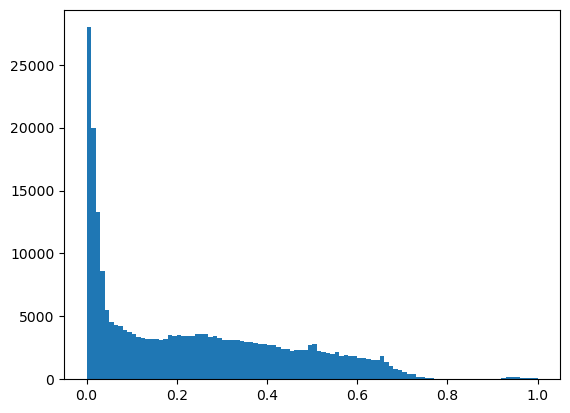

In [181]:
%matplotlib inline
plt.figure()
plt.hist(final[mask]['P_2'],bins=100,log=False)
plt.show()

## **TRASH**

In [ ]:
# pdf_dict = split_training.pdfs_from_sample(
#     training_sample,
#     label_column="ts_truth_type",
#     scols=["best_sed_id", "Teff_best", "logg_best", 'FeH_best'],
#     compute_weight=True,
#     weight_method="f_classif",
#     exclude_scols=False,
#     selectKbest=None,
#     bins=1000,
#     interp=False,
#     custo_bins_interp=[("Teff_best", teff_values, False),("logg_best", logg_values, False),("FeH_best", feh_values, False),('best_sed_id', sed_id_bins,None)],
#     recenter_bins=True,
#     normalize=True
# )

In [ ]:
class SPLIT:
    """
    Prototype classification with optional:
    - feature weights (f_classif)
    - class priors
    - variance (chi2-like distance)
    """

    def __init__(self, training_table, label_column,
                 ignore_columns=None, select_columns=None,
                 use_variance=False,
                 use_weights=False,
                 use_priors=None):

        self.label_column = label_column
        self.use_variance = bool(use_variance)
        self.use_weights = bool(use_weights)

        # --- feature selection ---
        if select_columns is not None:
            all_cols = [c for c in select_columns if c != label_column]
        else:
            if ignore_columns is None:
                ignore_columns = []
            all_cols = [c for c in training_table.columns
                        if c not in ignore_columns
                        and c != label_column]

        self.feature_columns = all_cols

        # --- extract X / y ---
        X = training_table[self.feature_columns].values.astype(float)
        y = training_table[label_column].values

        self.class_labels = np.unique(y)

        # --- priors ---
        if use_priors is None:
            self.use_priors = False
            self.priors = {cl: 1.0 / len(self.class_labels)
                           for cl in self.class_labels}
        else:
            self.use_priors = True
            if isinstance(use_priors, dict):
                self.priors = use_priors
            else:
                self.priors = {
                    cl: use_priors[i]
                    for i, cl in enumerate(self.class_labels)
                }

        # --- global normalisation ---
        self.mu_global = np.nanmean(X, axis=0)
        self.std_global = np.nanstd(X, axis=0)
        self.std_global[self.std_global == 0] = 1.0

        Z = (X - self.mu_global) / self.std_global

        # --- split by class ---
        self.class_Z = {cl: Z[y == cl] for cl in self.class_labels}

        # --- containers ---
        self.prototypes_mean = {}
        self.prototypes_var = {}
        self.feature_weights = None

        # --- compute weights if requested ---
        if self.use_weights:
            self.feature_weights = self._compute_feature_weights(Z, y)
        else:
            self.feature_weights = np.ones(Z.shape[1]) / Z.shape[1]

    # --------------------------------------------------
    # Feature weights (F-test)
    # --------------------------------------------------
    def _compute_feature_weights(self, Z, y):
        F, _ = f_classif(Z, y)
        F = np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)

        if np.all(F == 0):
            w = np.ones_like(F)
        else:
            w = F

        return w / np.sum(w)

    # --------------------------------------------------
    # Prototypes
    # --------------------------------------------------
    def compute_class_prototypes(self):
        """
        Compute class prototypes.
        Returns dict for inspection.
        """
        out = {}

        for cl in self.class_labels:
            Zc = self.class_Z[cl]

            mu = np.nanmean(Zc, axis=0)
            self.prototypes_mean[cl] = mu

            if self.use_variance:
                var = np.nanvar(Zc, axis=0)
                var[var == 0] = 1.0
                self.prototypes_var[cl] = var

            out[cl] = {"mean": mu}

        if self.use_weights:
            out["feature_weights"] = dict(
                zip(self.feature_columns, self.feature_weights)
            )

        return out

    # --------------------------------------------------
    # Classification
    # --------------------------------------------------
    def classify(self, new_table, return_distances=False):

        df = new_table.copy()

        X = df[self.feature_columns].values.astype(float)
        Z = (X - self.mu_global) / self.std_global

        N = len(Z)
        dist = {}

        for cl in self.class_labels:
            mu = self.prototypes_mean[cl]
            diff2 = (Z - mu) ** 2

            if self.use_variance:
                var = self.prototypes_var[cl]
                diff2 = diff2 / var

            d = np.nansum(self.feature_weights * diff2, axis=1)

            if self.use_priors:
                d = d - np.log(self.priors[cl])

            dist[cl] = d

        predicted = np.array([
            min(dist, key=lambda c: dist[c][i])
            for i in range(N)
        ])

        df["source_type"] = predicted

        if return_distances:
            for cl in self.class_labels:
                df[f"dist_{cl}"] = dist[cl]

        return df


In [ ]:
split = SPLIT(training_sample, 'ts_truth_type',
                ignore_columns=['source_id', 'mt_match_objectId'], use_variance=True, use_weights=True)

In [ ]:
prototypes = split.compute_class_prototypes()

In [ ]:
prototypes['feature_weights']

In [ ]:
splitted = split.classify(training_sample)

In [ ]:
splitted[splitted['ts_truth_type'] == 2]

In [ ]:
len(splitted[(splitted['ts_truth_type'] ==2) & (splitted['source_type'] ==2)])

<!-- def list_to_pdf(data, bins=100, xrange=None, smooth_eps=1e-9, interp=False, recenter_bins=True):
    if recenter_bins==True and not isinstance(bins, int):
        bins = recenter_from_edges(bins)
    counts, bin_edges = np.histogram(data, bins=bins, range=xrange, density=True)

    counts = counts + smooth_eps
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    if interp=='pchip':
        pdf = sip.PchipInterpolator(bin_centers, counts)
    else:
        pdf = sip.interp1d(bin_centers, counts, kind=interp, bounds_error=False, fill_value=smooth_eps)
    return pdf


def posterior_probability(y, pdf_f, pdf_g, prior_f=0.5, prior_g=0.5):
    pf = pdf_f(y)
    pg = pdf_g(y)

    denom = pf * prior_f + pg * prior_g
    if np.any(denom == 0):
        return np.nan
    prob = (pf * prior_f) / denom
    return prob


def prob_plot(data_f, data_g, vals, bins=50, interp=False, f_label='f', g_label='g', recenter_bins=False):
    pdf_f = list_to_pdf(data_f, interp=interp, bins=bins, recenter_bins=recenter_bins)
    pdf_g = list_to_pdf(data_g, interp=interp, bins=bins, recenter_bins=recenter_bins)

    if isinstance(bins, (list,np.ndarray)):
        x = bins
        if recenter_bins==True:
            bins = recenter_from_edges(bins)
    elif isinstance(bins, int):
        funcmin, funcmax = min(min(data_f),min(data_g)), max(max(data_f),max(data_g))
        x=np.arange(funcmin, funcmax, (funcmax-funcmin)/bins)
        if recenter_bins==True:
            x = center_bins(x)
    else:
        raise ValueError('Use "discrete" or "continue".')

    plt.figure(figsize=(6,5))
    plt.plot(x, pdf_f(x), c='k', linestyle='--', label=f_label)
    plt.hist(data_f, bins=bins, density=True, alpha=0.5)
    plt.plot(x, pdf_g(x),  c='k', linestyle=':', label=g_label)
    plt.hist(data_g, bins=bins, density=True, alpha=0.5)

    vals = [vals] if not isinstance(vals,(list,np.ndarray)) else vals 
    cmap = plt.get_cmap("tab10")
    for i, v in enumerate(vals):
        prob_v = posterior_probability(v, pdf_f, pdf_g)
        plt.axvline(v,0, 1, label=f"x: {v}, prob_f: {prob_v:.5f}", c=cmap(i))
        
    plt.legend()
    plt.show()


    
     -->